In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.8 MB/s eta 0:00:00


# Import Libs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import skfuzzy as fuzz
import time

# Internal metrics calculation

In [3]:

def calculate_internal_metrics(X, labels):
    if len(set(labels)) > 1:
        silhouette = silhouette_score(X, labels)
        calinski = calinski_harabasz_score(X, labels)
        davies = davies_bouldin_score(X, labels)
        return {"Silhouette": silhouette, "Calinski-Harabasz": calinski, "Davies-Bouldin": davies}
    return {"Silhouette": -1, "Calinski-Harabasz": -1, "Davies-Bouldin": -1}

# External metrics calculation
def calculate_external_metrics(y_true, labels):
    if len(set(labels)) > 1:
        ari = adjusted_rand_score(y_true, labels)
        nmi = normalized_mutual_info_score(y_true, labels)
        return {"ARI": ari, "NMI": nmi}
    return {"ARI": -1, "NMI": -1}

# WCSS calculation
def calculate_wcss(data, labels, centers):
    wcss = 0
    for i, center in enumerate(centers):
        cluster_points = data[labels == i]
        wcss += ((cluster_points - center) ** 2).sum()
    return wcss

# Load and preprocess real-world dataset

In [4]:
def load_data():
    iris = load_iris()
    X = iris.data
    y_true = iris.target

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y_true

# Visualization function

In [5]:
def visualize_results(X, y_true, labels_dict):
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    num_plots = len(labels_dict) + 1
    cols = 3
    rows = (num_plots // cols) + int(num_plots % cols > 0)

    plt.figure(figsize=(5 * cols, 4 * rows))
    for idx, (name, labels) in enumerate(labels_dict.items(), 1):
        plt.subplot(rows, cols, idx)
        sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='tab10', legend=None, s=30)
        plt.title(f'{name} Clustering')
    plt.subplot(rows, cols, num_plots)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, palette='tab10', legend=None, s=30)
    plt.title('True Labels')
    plt.tight_layout()
    plt.show()

# Main function


Clustering Metrics:
K-Means: {'Silhouette': np.float64(0.4798814508199817), 'Calinski-Harabasz': np.float64(157.36015312192248), 'Davies-Bouldin': np.float64(0.7893630242997912), 'ARI': 0.432804702527474, 'NMI': np.float64(0.5895674488004073), 'WCSS': np.float64(191.0247368531797), 'Time': 0.24753308296203613}
MiniBatch K-Means: {'Silhouette': np.float64(0.46423369721472235), 'Calinski-Harabasz': np.float64(240.7965504198436), 'Davies-Bouldin': np.float64(0.8301835053826414), 'ARI': 0.6116890434857991, 'NMI': np.float64(0.6572371542667134), 'WCSS': np.float64(140.6797858178387), 'Time': 0.0670461654663086}
DBSCAN: {'Silhouette': np.float64(0.35651648142700726), 'Calinski-Harabasz': np.float64(84.51033032484679), 'Davies-Bouldin': np.float64(7.124056948818223), 'ARI': 0.4420986685885924, 'NMI': np.float64(0.5114298559522713), 'Time': 0.03172039985656738}
Agglomerative: {'Silhouette': np.float64(0.4466890410285909), 'Calinski-Harabasz': np.float64(222.71916382215363), 'Davies-Bouldin': 

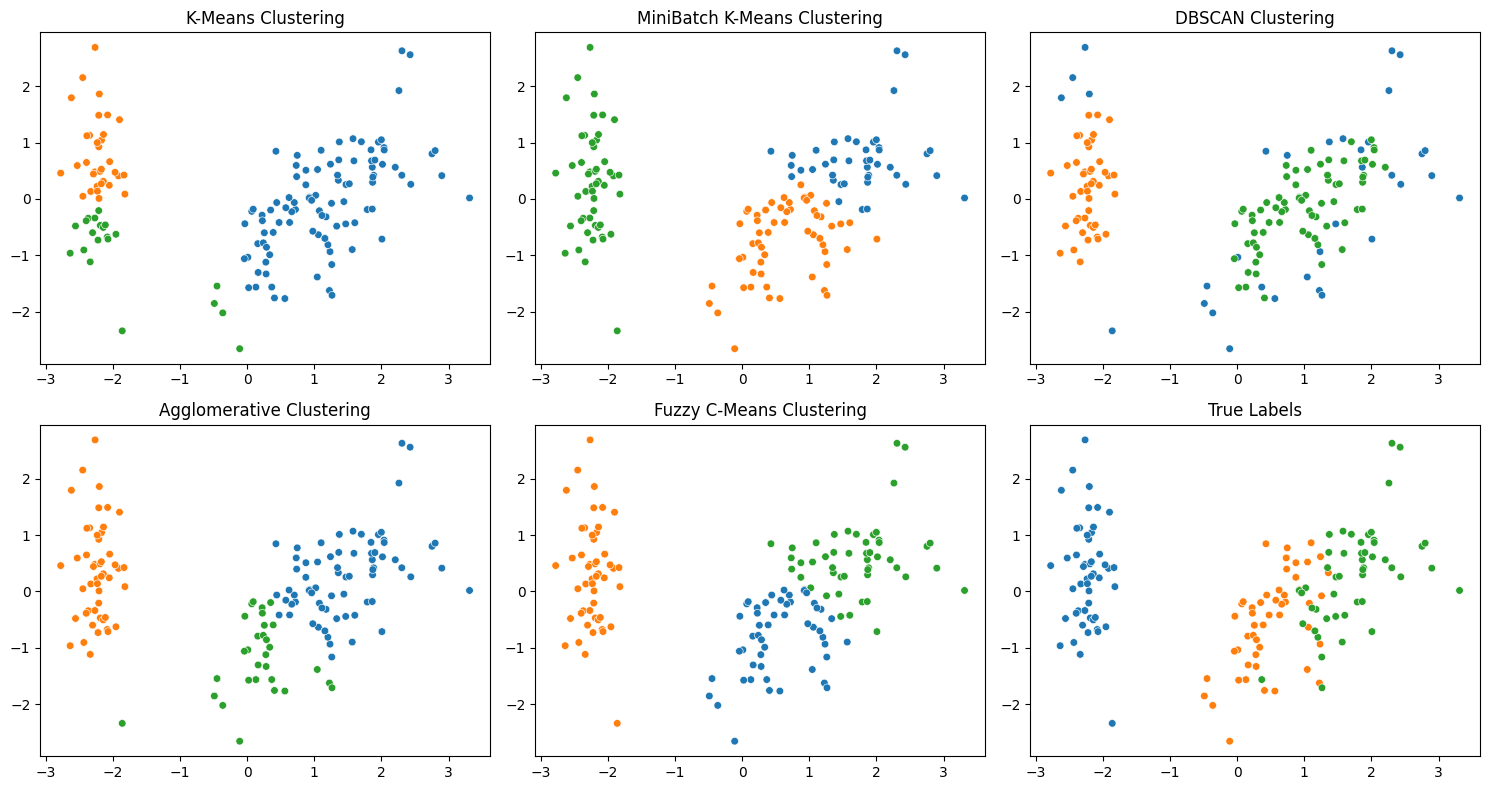

In [6]:

X, y_true = load_data()

# Initialize dictionaries for metrics and labels
metrics = {}
labels_dict = {}

# K-Means
start_time = time.time()
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
kmeans_labels = kmeans.labels_
kmeans_wcss = calculate_wcss(X, kmeans_labels, kmeans.cluster_centers_)
kmeans_internal = calculate_internal_metrics(X, kmeans_labels)
kmeans_external = calculate_external_metrics(y_true, kmeans_labels)
metrics['K-Means'] = {
    **kmeans_internal,
    **kmeans_external,
    "WCSS": kmeans_wcss,
    "Time": time.time() - start_time,
}
labels_dict['K-Means'] = kmeans_labels

# MiniBatch K-Means
start_time = time.time()
mb_kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=20).fit(X)
mb_kmeans_labels = mb_kmeans.labels_
mb_kmeans_wcss = calculate_wcss(X, mb_kmeans_labels, mb_kmeans.cluster_centers_)
mb_kmeans_internal = calculate_internal_metrics(X, mb_kmeans_labels)
mb_kmeans_external = calculate_external_metrics(y_true, mb_kmeans_labels)
metrics['MiniBatch K-Means'] = {
    **mb_kmeans_internal,
    **mb_kmeans_external,
    "WCSS": mb_kmeans_wcss,
    "Time": time.time() - start_time,
}
labels_dict['MiniBatch K-Means'] = mb_kmeans_labels

# DBSCAN
start_time = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X)
dbscan_labels = dbscan.labels_
dbscan_internal = calculate_internal_metrics(X, dbscan_labels)
dbscan_external = calculate_external_metrics(y_true, dbscan_labels)
metrics['DBSCAN'] = {**dbscan_internal, **dbscan_external, "Time": time.time() - start_time}
labels_dict['DBSCAN'] = dbscan_labels

# Agglomerative Clustering
start_time = time.time()
agglo = AgglomerativeClustering(n_clusters=3).fit(X)
agglo_labels = agglo.labels_
agglo_internal = calculate_internal_metrics(X, agglo_labels)
agglo_external = calculate_external_metrics(y_true, agglo_labels)
metrics['Agglomerative'] = {**agglo_internal, **agglo_external, "Time": time.time() - start_time}
labels_dict['Agglomerative'] = agglo_labels

# Fuzzy C-Means
start_time = time.time()
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X.T, c=3, m=2, error=0.005, maxiter=1000)
fcm_labels = np.argmax(u, axis=0)
fcm_internal = calculate_internal_metrics(X, fcm_labels)
fcm_external = calculate_external_metrics(y_true, fcm_labels)
metrics['Fuzzy C-Means'] = {**fcm_internal, **fcm_external, "Time": time.time() - start_time}
labels_dict['Fuzzy C-Means'] = fcm_labels

# Print metrics
print("\nClustering Metrics:")
for name, metric in metrics.items():
    print(f"{name}: {metric}")

# Visualize results
visualize_results(X, y_true, labels_dict)